<a href="https://colab.research.google.com/github/Aadiie/EDA-TXHousing/blob/main/22BDS0424.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# phase 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree, connected_components
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/txhousing.csv"
df = pd.read_csv(url)
df.head()


,rownames,city,year,month,sales,volume,median,listings,inventory,date
0,1,Abilene,2000,1,72.0,5380000.0,71400.0,701.0,6.3,2000.000000
1,2,Abilene,2000,2,98.0,6505000.0,58700.0,746.0,6.6,2000.083333
2,3,Abilene,2000,3,130.0,9285000.0,58100.0,784.0,6.8,2000.166667
3,4,Abilene,2000,4,98.0,9730000.0,68600.0,785.0,6.9,2000.250000
4,5,Abilene,2000,5,141.0,10590000.0,67300.0,794.0,6.8,2000.333333


In [33]:
# Dataset dimensions

print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)


Shape of dataset: (8602, 10)

Column names: ['rownames', 'city', 'year', 'month', 'sales', 'volume', 'median', 'listings', 'inventory', 'date']

Data types:
 rownames       int64
city          object
year           int64
month          int64
sales        float64
volume       float64
median       float64
listings     float64
inventory    float64
date         float64
dtype: object


In [34]:
# Summary Statistics
print("\nSummary statistics:\n", df.describe(include='all'))


Summary statistics:
            rownames     city         year        month        sales  \
count   8602.000000     8602  8602.000000  8602.000000  8034.000000   
unique          NaN       46          NaN          NaN          NaN   
top             NaN  Abilene          NaN          NaN          NaN   
freq            NaN      187          NaN          NaN          NaN   
mean    4301.500000      NaN  2007.299465     6.406417   549.564600   
std     2483.327841      NaN     4.502923     3.441932  1110.737179   
min        1.000000      NaN  2000.000000     1.000000     6.000000   
25%     2151.250000      NaN  2003.000000     3.000000    86.000000   
50%     4301.500000      NaN  2007.000000     6.000000   169.000000   
75%     6451.750000      NaN  2011.000000     9.000000   467.000000   
max     8602.000000      NaN  2015.000000    12.000000  8945.000000   

              volume         median      listings    inventory         date  
count   8.034000e+03    7986.000000   7178.0000

In [35]:
#  Data Handling
print("\nTop 5 rows:\n", df.head())
print("\nNumber of unique cities:", df['city'].nunique())
print("\nData for Austin:\n", df[df['city'] == 'Austin'].head())


Top 5 rows:
    rownames     city  year  month  sales      volume   median  listings  \
0         1  Abilene  2000      1   72.0   5380000.0  71400.0     701.0   
1         2  Abilene  2000      2   98.0   6505000.0  58700.0     746.0   
2         3  Abilene  2000      3  130.0   9285000.0  58100.0     784.0   
3         4  Abilene  2000      4   98.0   9730000.0  68600.0     785.0   
4         5  Abilene  2000      5  141.0  10590000.0  67300.0     794.0   

   inventory         date  
0        6.3  2000.000000  
1        6.6  2000.083333  
2        6.8  2000.166667  
3        6.9  2000.250000  
4        6.8  2000.333333  

Number of unique cities: 46

Data for Austin:
      rownames    city  year  month   sales       volume    median  listings  \
561       562  Austin  2000      1  1025.0  173053635.0  133700.0    3084.0   
562       563  Austin  2000      2  1277.0  226038438.0  134000.0    2989.0   
563       564  Austin  2000      3  1603.0  298557656.0  136700.0    3042.0   
564

In [36]:
# Sorting by sales
sorted_df = df.sort_values(by='sales', ascending=False)
print("\nTop sales:\n", sorted_df.head())


Top sales:
       rownames     city  year  month   sales        volume    median  \
3739      3740  Houston  2015      7  8945.0  2.568157e+09  217600.0   
3630      3631  Houston  2006      6  8628.0  1.795898e+09  155200.0   
3715      3716  Houston  2013      7  8468.0  2.168721e+09  187800.0   
3738      3739  Houston  2015      6  8449.0  2.490239e+09  222400.0   
3713      3714  Houston  2013      5  8439.0  2.121509e+09  186100.0   

      listings  inventory         date  
3739   23875.0        3.4  2015.500000  
3630   36281.0        5.6  2006.416667  
3715   21497.0        3.3  2013.500000  
3738   22311.0        3.2  2015.416667  
3713   20526.0        3.3  2013.333333  


In [37]:
# Data Cleaning
# Missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 rownames        0
city            0
year            0
month           0
sales         568
volume        568
median        616
listings     1424
inventory    1467
date            0
dtype: int64


In [38]:
# Filling missing values for sales with median
df['sales'] = df['sales'].fillna(df['sales'].median())

In [39]:
# Drop rows with too many missing values
df.dropna(thresh=len(df.columns)-2, inplace=True)

In [40]:
# Remove duplicates
df.drop_duplicates(inplace=True)

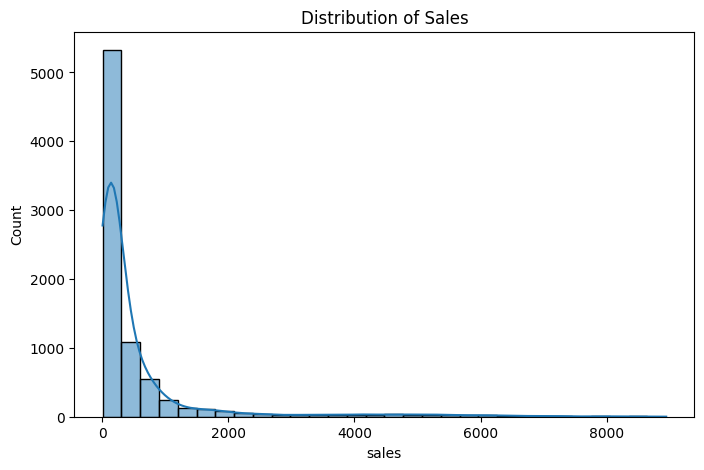

In [41]:
# Univariate Analysis
plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.show()


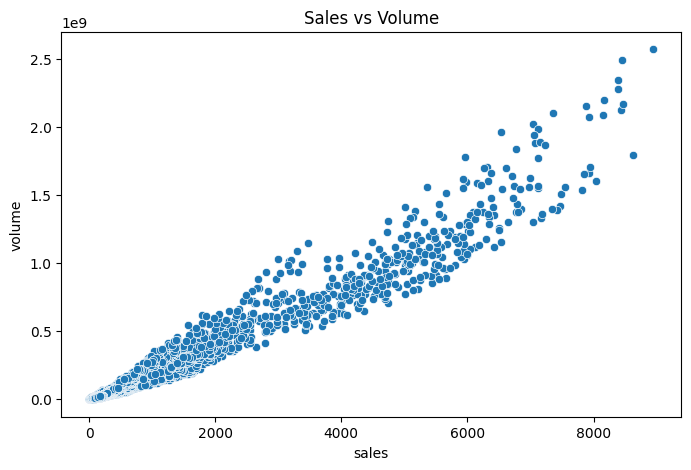

In [42]:
# Bivariate Analysis
plt.figure(figsize=(8,5))
sns.scatterplot(x='sales', y='volume', data=df)
plt.title('Sales vs Volume')
plt.show()

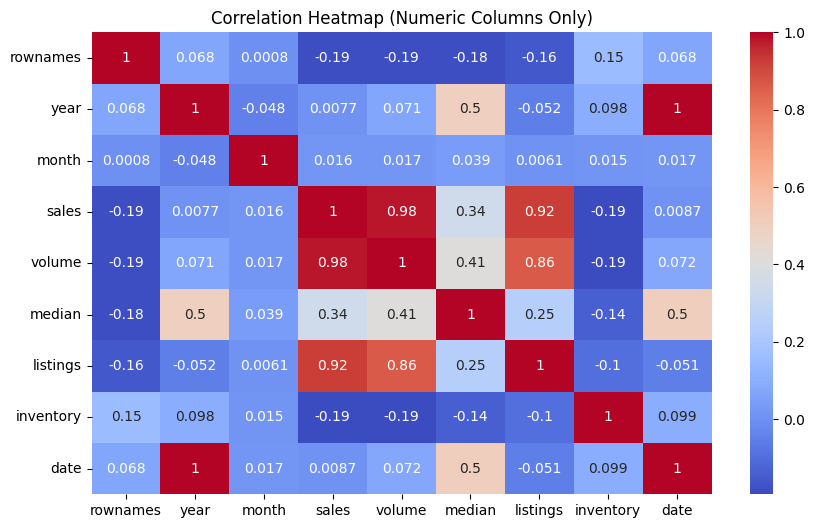

In [43]:
#  Multivariate Analysis
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=[np.number])  # keep only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()


In [44]:
# Phase 2
# part 1 - Module 4
# Calculate skewness for key numerical columns
skewness = df[['sales', 'volume', 'median', 'listings', 'inventory']].skew()
print("Skewness of the variables:\n", skewness)

Skewness of the variables:
 sales        3.879539
volume       4.292920
median       0.840855
listings     3.888757
inventory    3.807512
dtype: float64


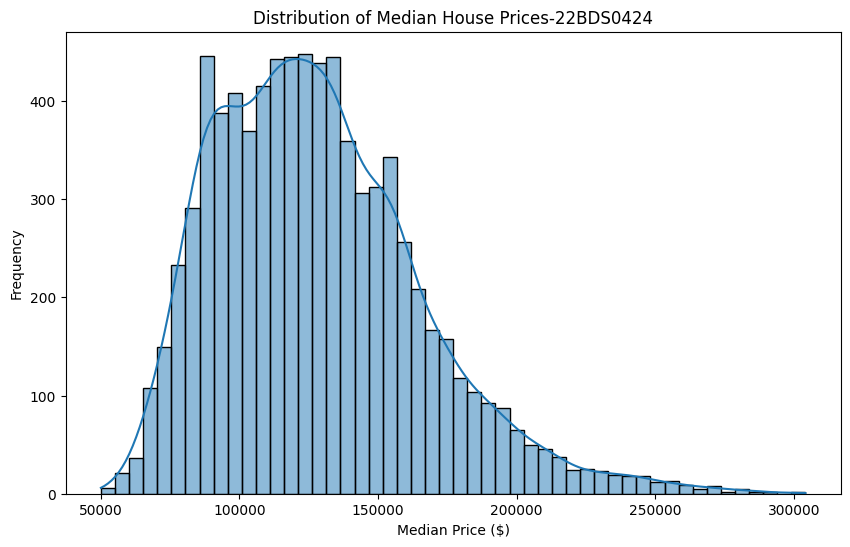

In [45]:
# Plotting the distribution of the median house price
plt.figure(figsize=(10, 6))
sns.histplot(df['median'], bins=50, kde=True)
plt.title('Distribution of Median House Prices-22BDS0424')
plt.xlabel('Median Price ($)')
plt.ylabel('Frequency')
plt.show()

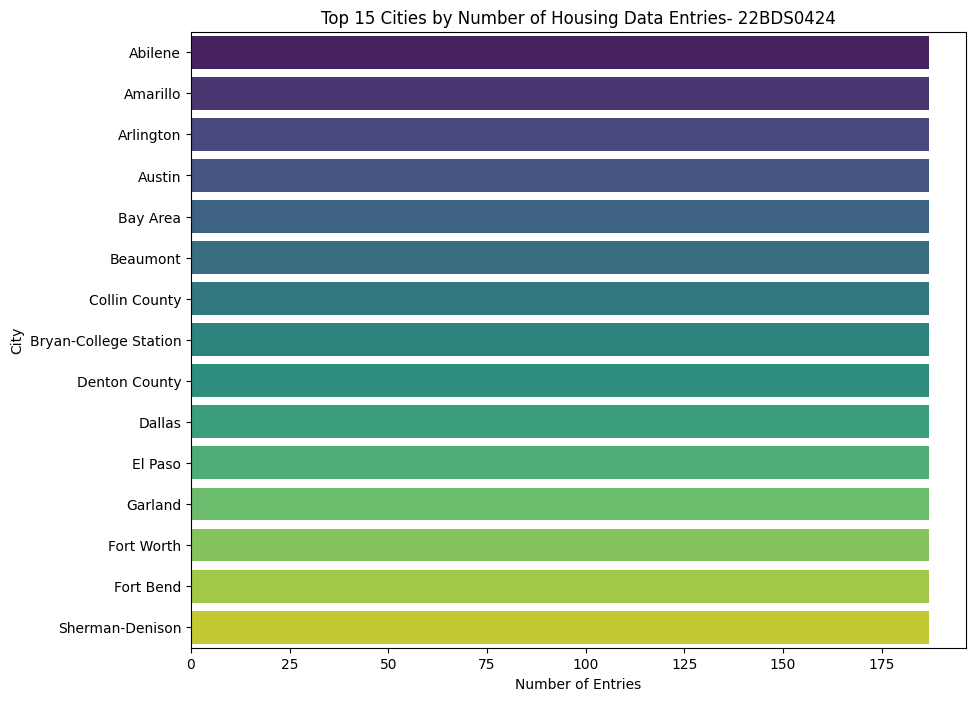

In [46]:
# Plotting the top 15 cities with the most data entries
plt.figure(figsize=(10, 8))
city_counts = df['city'].value_counts().nlargest(15)
sns.barplot(x=city_counts.values, y=city_counts.index, hue=city_counts.index, palette='viridis', legend=False)
plt.title('Top 15 Cities by Number of Housing Data Entries- 22BDS0424')
plt.xlabel('Number of Entries')
plt.ylabel('City')
plt.show()

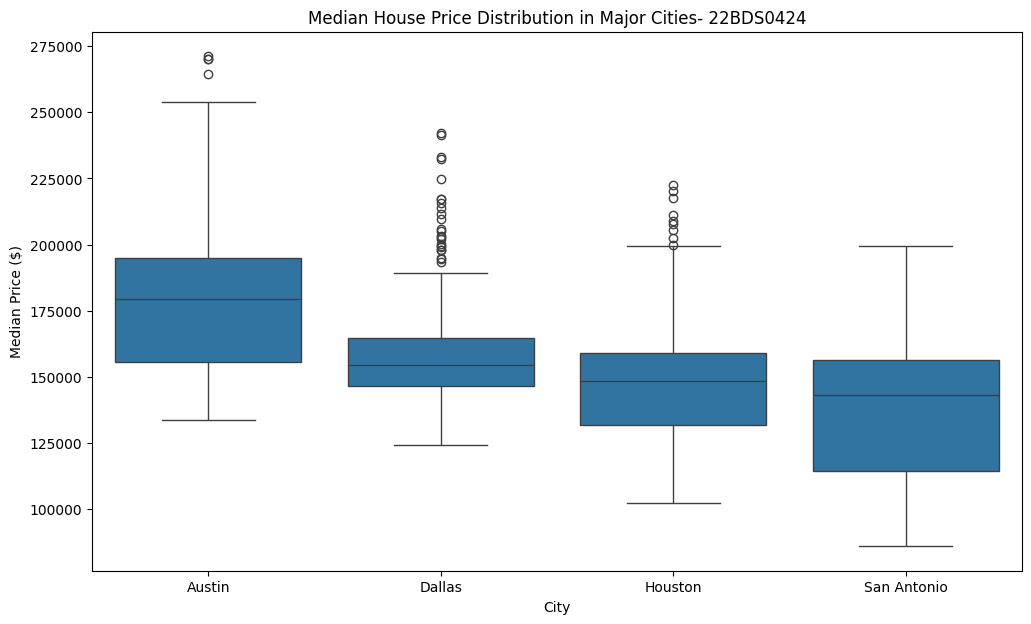

In [47]:
# Comparing median house prices in major Texas cities
major_cities = ['Houston', 'Dallas', 'Austin', 'San Antonio']
df_cities = df[df['city'].isin(major_cities)]

plt.figure(figsize=(12, 7))
sns.boxplot(x='city', y='median', data=df_cities)
plt.title('Median House Price Distribution in Major Cities- 22BDS0424')
plt.xlabel('City')
plt.ylabel('Median Price ($)')
plt.show()

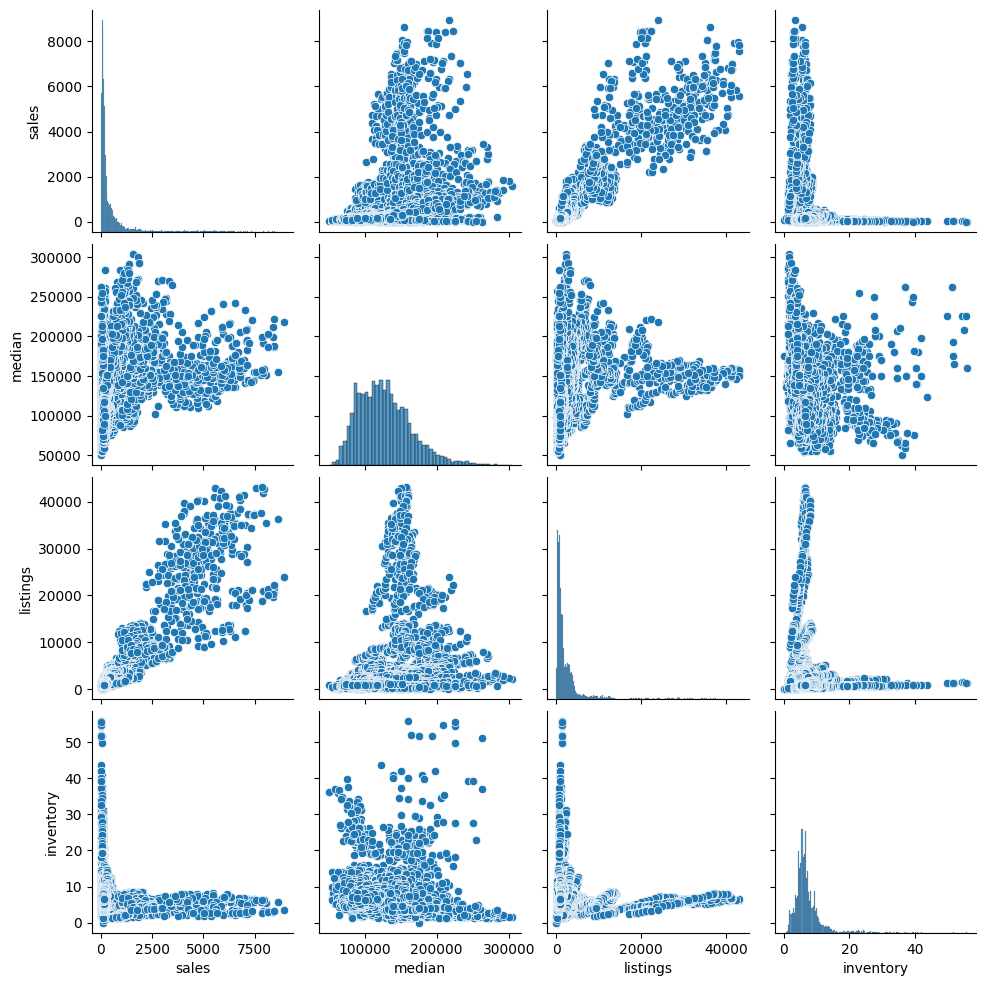

In [48]:
# Pairplot for a subset of key numerical variables
sns.pairplot(df[['sales', 'median', 'listings', 'inventory']])
plt.show()

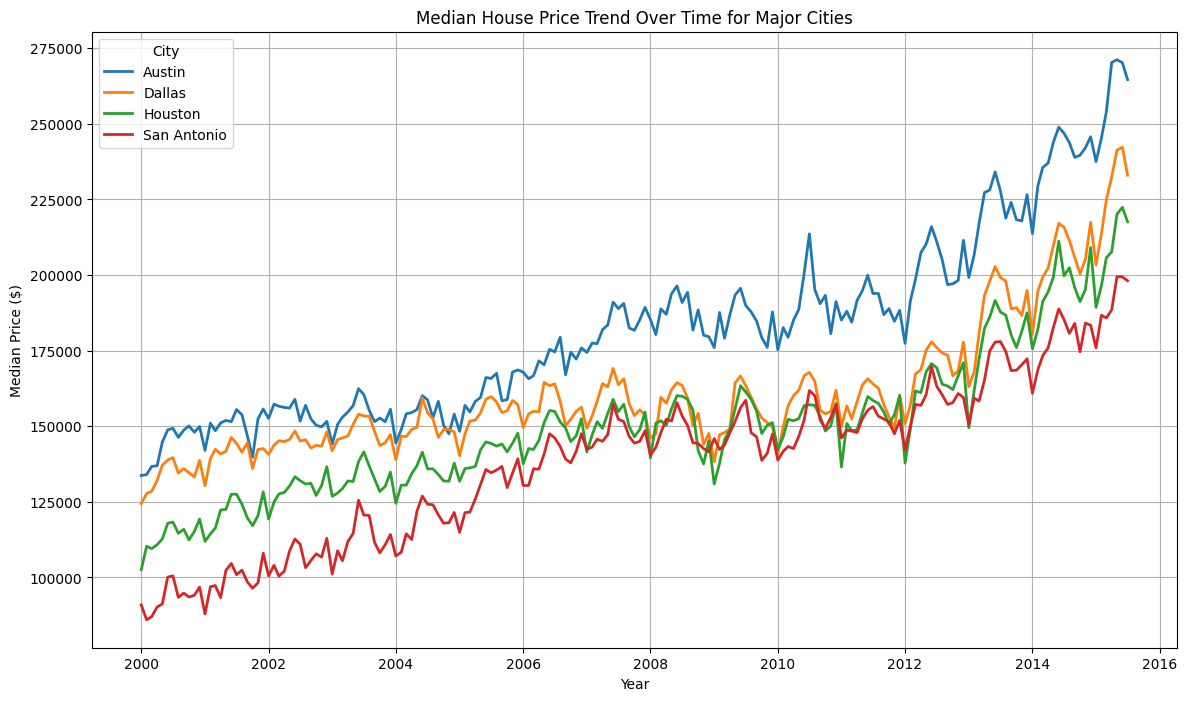

In [49]:
#  plotting the data using the corrected df_cities dataframe
df['date_time'] = pd.to_datetime(df[['year', 'month']].assign(day=1))


major_cities = ['Houston', 'Dallas', 'Austin', 'San Antonio']
df_cities = df[df['city'].isin(major_cities)]


plt.figure(figsize=(14, 8))
sns.lineplot(data=df_cities, x='date_time', y='median', hue='city', lw=2)
plt.title('Median House Price Trend Over Time for Major Cities')
plt.xlabel('Year')
plt.ylabel('Median Price ($)')
plt.legend(title='City')
plt.grid(True)
plt.show()

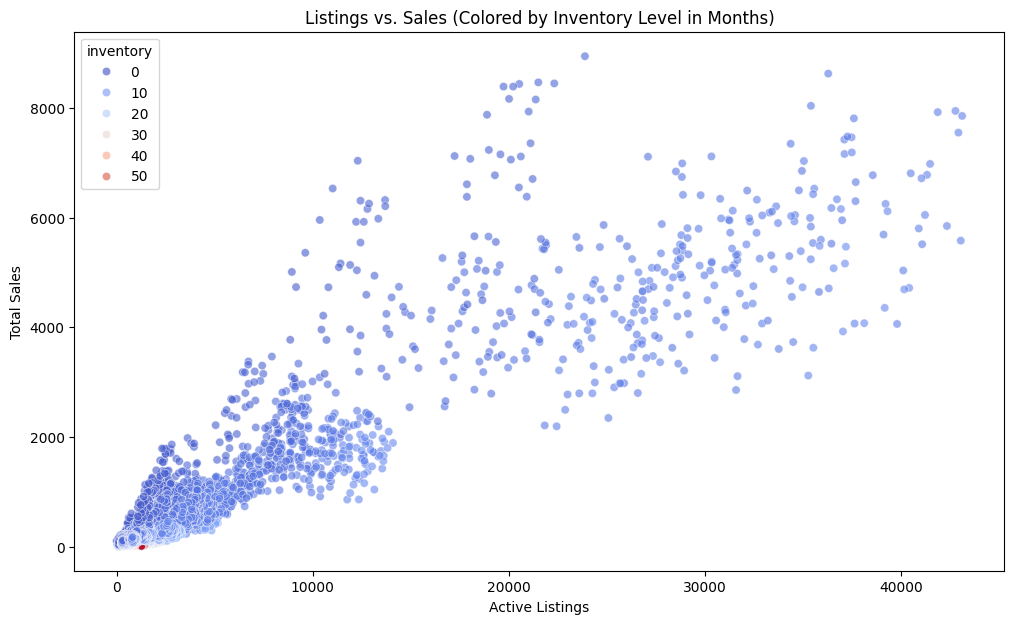

In [50]:
# Scatter plot of listings vs. sales, colored by inventory
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='listings', y='sales', hue='inventory', palette='coolwarm', alpha=0.6)
plt.title('Listings vs. Sales (Colored by Inventory Level in Months)')
plt.xlabel('Active Listings')
plt.ylabel('Total Sales')
plt.show()

Successfully found 3 clusters.


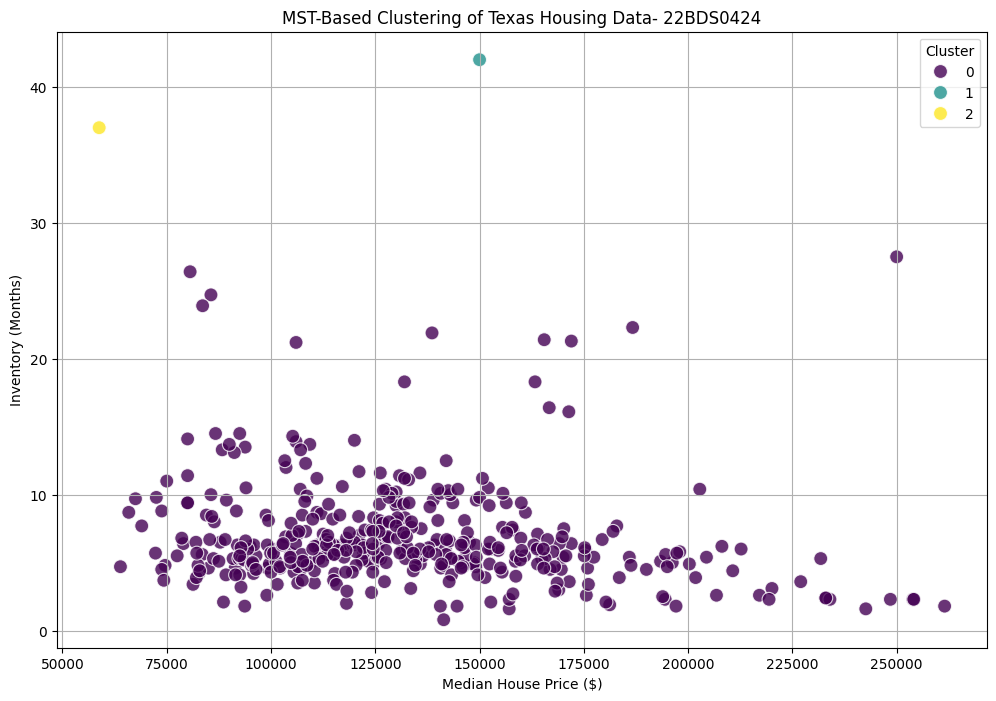

In [51]:
# Part 2 - Module 5
# Building the Minimum Spanning Tree (MST)

features = ['median', 'inventory']
df_cluster = df[features].dropna()

df_sample = df_cluster.sample(n=400, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

distance_matrix = squareform(pdist(X_scaled, 'euclidean'))

mst = minimum_spanning_tree(distance_matrix)

num_clusters = 4
edges_to_cut = num_clusters - 1

mst_edges = mst.toarray()
edge_weights = mst_edges[mst_edges.nonzero()]
sorted_weights = np.sort(edge_weights)[::-1]

threshold = sorted_weights[edges_to_cut - 1]
mst_edges[mst_edges > threshold] = 0

n_components, labels = connected_components(mst_edges)
df_sample['cluster'] = labels

print(f"Successfully found {n_components} clusters.")

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=df_sample['median'],
    y=df_sample['inventory'],
    hue=df_sample['cluster'],
    palette='viridis',
    s=100,
    alpha=0.8
)

plt.title('MST-Based Clustering of Texas Housing Data- 22BDS0424')
plt.xlabel('Median House Price ($)')
plt.ylabel('Inventory (Months)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [52]:
#Phase 3. Module 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis, TruncatedSVD
from sklearn.manifold import MDS, Isomap, TSNE


from minisom import MiniSom


import warnings
warnings.filterwarnings('ignore')

# Data Preparation for Module 6



feature_cols = ['sales', 'volume', 'median', 'listings', 'inventory']
features_df = df[feature_cols]


df_filled = features_df.fillna(features_df.median())


scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_filled)

print("Data prepared and scaled. Shape:", df_scaled.shape)

Data prepared and scaled. Shape: (7994, 5)



--- PCA Results ---
Explained Variance Ratio by PC1 and PC2:
[0.61026866 0.19641703]
Total variance explained by 2 components: 80.67%


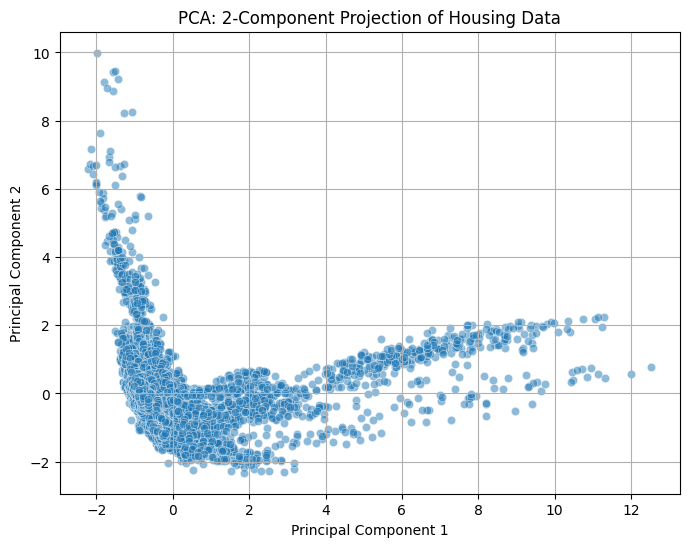

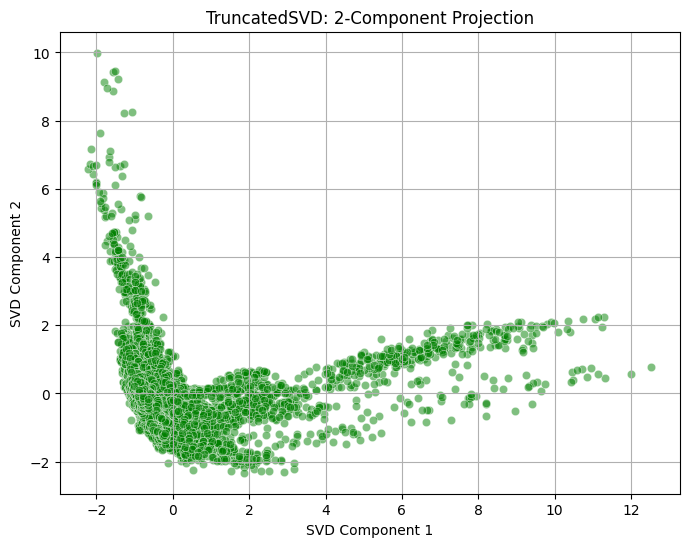

In [53]:
# Principal Component Analysis (PCA)

pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)


df_pca = pd.DataFrame(data=df_pca, columns=['PC1', 'PC2'])

print("\n--- PCA Results ---")
print("Explained Variance Ratio by PC1 and PC2:")
print(pca.explained_variance_ratio_)
print(f"Total variance explained by 2 components: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

# Plot the PCA results
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.5)
plt.title('PCA: 2-Component Projection of Housing Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Singular Value Decomposition (SVD)

svd = TruncatedSVD(n_components=2, random_state=42)
df_svd = svd.fit_transform(df_scaled)
df_svd = pd.DataFrame(data=df_svd, columns=['SVD1', 'SVD2'])

# Plot the SVD
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SVD1', y='SVD2', data=df_svd, alpha=0.5, color='green')
plt.title('TruncatedSVD: 2-Component Projection')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.grid(True)
plt.show()

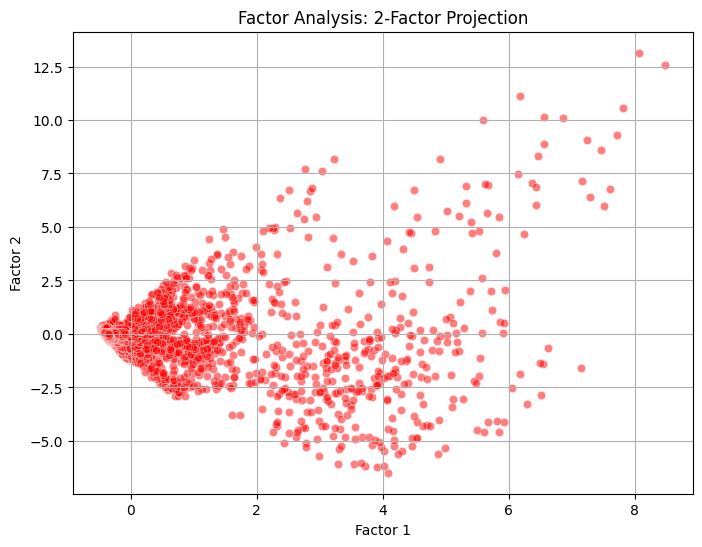

In [54]:
#  Factor Analysis (FA)
fa = FactorAnalysis(n_components=2, random_state=42)
df_fa = fa.fit_transform(df_scaled)
df_fa = pd.DataFrame(data=df_fa, columns=['Factor1', 'Factor2'])

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Factor1', y='Factor2', data=df_fa, alpha=0.5, color='red')
plt.title('Factor Analysis: 2-Factor Projection')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.grid(True)
plt.show()

In [55]:
# Module 7
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#  1. Data Preparation


target_variable = 'median'
y = df[target_variable]


features = ['sales', 'volume', 'listings', 'inventory', 'city']
X = df[features]


X_processed = pd.get_dummies(X, columns=['city'], drop_first=True)


y = y.fillna(y.median())
X_processed = X_processed.fillna(X_processed.median())


X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (6395, 49)
Testing features shape: (1599, 49)


In [56]:
#  2. Constructing the Linear Regression Model


lr_model = LinearRegression()


print("\nTraining the Linear Regression model...")
lr_model.fit(X_train_scaled, y_train)
print("Model training complete.")

#  3. Evaluation and Computing Accuracy


y_pred_lr = lr_model.predict(X_test_scaled)


mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("\n--- Model Evaluation Results ---")
print(f"  R-squared (R²): {r2:.4f}")
print(f"  Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"  Mean Squared Error (MSE): {mse:,.2f}")
print(f"  Root Mean Squared Error (RMSE): ${rmse:,.2f}")


Training the Linear Regression model...
Model training complete.

--- Model Evaluation Results ---
  R-squared (R²): 0.6902
  Mean Absolute Error (MAE): $15,973.15
  Mean Squared Error (MSE): 411,923,642.76
  Root Mean Squared Error (RMSE): $20,295.90
